<a href="https://colab.research.google.com/github/LinjingBi/ai_robotics_lab/blob/main/week9/RL_modelfree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# SEMTM0016 Week 21: Value based Reinforcement Learning - Model-free Methods

## Instructions
1.   To start this notebook, please duplicate this notebook at first:
  - Choose "File => Save a copy in Drive" and open/run it in Colab.
  - Or you can download the notebook and run it in your local jupyter notebook server.
2.   For the coding assignment and practice, please write your code at `### TODO ###` blocks or in a new cell. For analysis report, you are free to use as many blocks as you need.


# Section III: Model-free learning

### the second week

## Q3: Q Learning and Sarsa

In this part, you will complete the implementation of Q-Learning and Sarsa for the Cliff Walking task introduced in [Example 6.6 of Sutton's RL book (page 154)](http://incompleteideas.net/book/RLbook2020.pdf#page=154).

We implemented the CliffWalking environment for you by the following code. When you want to play with this environment class, first instantiate the class by specifying the number of rows `num_rows` and columns `num_cols` for the grid world (the initial point of the agent will be at `(num_rows - 1, 0)`), then use `step(action)` method to move a single step in this environment, and get the next state of the agent after the move:

- `action = 0`: move left (y coord - 1)
- `action = 1`: move up (x coord - 1)
- `action = 2`: move right (y coord + 1)
- `action = 3`: move down (x coord + 1)

The state of this task is the coordinates of the agent in the grid world, and we use a single integer `state_id = x_coord * num_cols + y_coord` to denote the id of the state. E.g., in a grid sized `(4, 12)`, `state_id = 15` means that the coordinates of the agent is at `(1, 3)` since `15 = 1 * 12 + 3`.

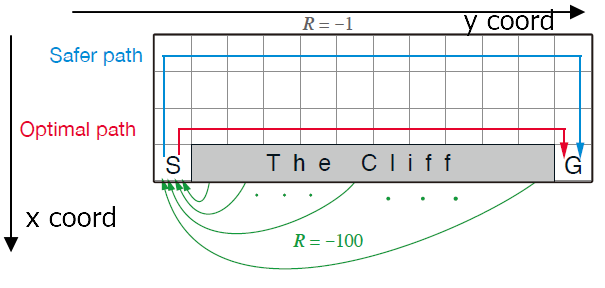

In [ ]:
import numpy as np
a = np.array([[1,2], [2,4]])
a.max(1)

array([2, 4])

In [ ]:
import numpy as np

seed_value=42
np.random.seed(seed_value)

class CliffWalking():
    def __init__(self, num_rows, num_cols):
        self.num_rows = num_rows
        self.num_cols = num_cols
        self.num_states = self.num_rows * self.num_cols
        self.grid = np.zeros((self.num_rows, self.num_cols), dtype=np.bool)
        self.grid[3, (self.num_rows + 1):(self.num_cols - 1)] = True
        self.mov = list(map(np.array, [[0, -1], [-1, 0], [0, 1], [1, 0]]))
        self.reset()

    def reset(self):
        self.loc = np.array([self.num_rows - 1, 0], dtype=np.int64)
        return self.state_id(self.loc)

    def state_id(self, state):
        return state[0] * self.num_cols + state[1]

    def step(self, action):
        self.loc += self.mov[action]
        self.loc[0] = 0 if self.loc[0] < 0 else (self.num_rows - 1) if self.loc[0] >= self.num_rows else self.loc[0]
        self.loc[1] = 0 if self.loc[1] < 0 else (self.num_cols - 1) if self.loc[1] >= self.num_cols else self.loc[1]
        next_state = self.state_id(self.loc)
        if self.grid[tuple(self.loc)]:
            self.reset() is ' '
            return next_state, -100, True
        else:
            if tuple(self.loc) == (self.num_rows - 1, self.num_cols - 1):
                return next_state, -1, True
            return next_state, -1, False

<>:29: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:29: SyntaxWarning: "is" with a literal. Did you mean "=="?
<ipython-input-1-8d2a013a03b6>:29: SyntaxWarning: "is" with a literal. Did you mean "=="?
  self.reset() is ' '


The first task for you is to implement an ϵ-greedy policy, a simple method to balance exploration and exploitation by choosing between exploration and exploitation randomly. See chapter 2 of Sutton's RL book for details.

$$ action = \begin{cases}\text{a random action} & \text{with probability }\epsilon \\ \arg \max_a Q(s, a) & \text{with probability }1 - \epsilon \end{cases} $$

Tips:
- Here `q_table` is a 2-D NumPy array with shape `(num_states, num_actions)`. `q_table[state, action]` denotes the Q-value for the state with id `state` and the action with id `action`.
- you may use `np.argmax` to simplify your implementation. [[NumPy Docs]](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html)

In [ ]:
num_rows, num_cols = 4, 12
env = CliffWalking(num_rows, num_cols)
num_episodes = 500
learning_rate = 0.5
gamma = 1.     # delay factor
epsilon = 0.1

np.random.RandomState(seed_value)

def epsilon_greedy(epsilon, q_table, state):
    if np.random.rand() < epsilon:
        ### TODO: randomly select an action from (0, 1, 2, 3) ###
        return np.random.choice(np.array([0, 1, 2, 3]))

        ### END TODO ###
    else:
        ### TODO: for current state, select the action that has the maximum Q-value in the Q-table ###
        return np.argmax(q_table[state])

        ### END TODO ###

Then you can complete the Sarsa and Q-learning implementations by implementing the update of Q-table.

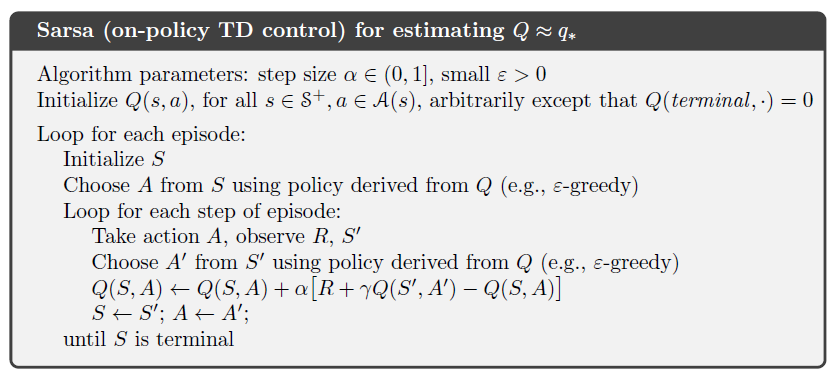

In [ ]:
# Sarsa
np.random.RandomState(seed_value)
def sarsa():
    sarsa_rewards = []
    q_table = np.random.rand(env.num_states, 4)
    q_table[num_rows * num_cols - 1, :] = 0.
    for episode in range(num_episodes):
        state = env.reset()
        action = epsilon_greedy(epsilon, q_table, state)
        cumulated_reward = 0
        while True:
            next_state, reward, done = env.step(action)
            cumulated_reward += reward
            next_action = epsilon_greedy(epsilon, q_table, next_state)
            ### TODO: implement the update of Q-table for Sarsa ###
            q_table[state, action] = q_table[state, action] + learning_rate*(reward + gamma*q_table[next_state, next_action] - q_table[state, action])
            ### END TODO ###
            if done:
                break
            state, action = next_state, next_action
        sarsa_rewards.append(cumulated_reward)
    return sarsa_rewards

In [ ]:
# Q-learning
np.random.RandomState(seed_value)
def q_learning():
    q_learning_rewards = []
    q_table = np.random.rand(env.num_states, 4)
    q_table[num_rows * num_cols - 1, :] = 0.
    for episode in range(num_episodes):
        state = env.reset()
        action = epsilon_greedy(epsilon, q_table, state)
        cumulated_reward = 0
        while True:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(epsilon, q_table, next_state)
            cumulated_reward += reward
            ### TODO: implement the update of Q-table for Q-Learning ###
            q_table[state, action] = q_table[state, action] + learning_rate*(reward + gamma*q_table[next_state].max() - q_table[state, action])
            ### END TODO ###
            if done:
                break
            state, action = next_state, next_action
        q_learning_rewards.append(cumulated_reward)
    return q_learning_rewards

# # Q-learning - answer from the solution
# def q_learning():
#     q_learning_rewards = []
#     q_table = np.random.rand(env.num_states, 4)
#     q_table[num_rows * num_cols - 1, :] = 0.
#     for episode in range(num_episodes):
#         state = env.reset()
#         cumulated_reward = 0
#         while True:
#             action = epsilon_greedy(epsilon, q_table, state)
#             next_state, reward, done = env.step(action)
#             cumulated_reward += reward
#             ### TODO: implement the update of Q-table for Q-Learning ###
#             q_table[state, action] += learning_rate * (reward + gamma * np.max(q_table[next_state, :]) - q_table[state, action])
#             ### END TODO ###
#             if done:
#                 break
#             state = next_state
#         q_learning_rewards.append(cumulated_reward)
#     return q_learning_rewards

Then we use the following code to run the Sarsa and Q-learning implementions, and compare their performance on the Cliff Walking task.

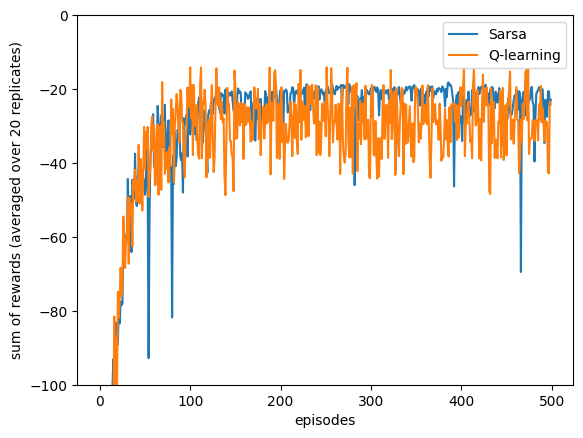

In [ ]:
import matplotlib.pyplot as plt
np.random.RandomState(seed_value)
num_replicate = 20
sarsa_rewards_avg = np.mean([sarsa() for _ in range(num_replicate)], axis=0)
q_learning_rewards_avg = np.mean([q_learning() for _ in range(num_replicate)], axis=0)
plt.plot(range(num_episodes), sarsa_rewards_avg, label='Sarsa')
plt.plot(range(num_episodes), q_learning_rewards_avg, label='Q-learning')
plt.ylim(-100, 0)
plt.xlabel('episodes')
plt.ylabel('sum of rewards (averaged over %d replicates)' % num_replicate)
plt.legend()
plt.show()

## Q4: Deep Q Network

Please check [Playing Atari with Deep Reinforcement Learning](https://arxiv.org/abs/1312.5602) for the details of the DQN algorithm.

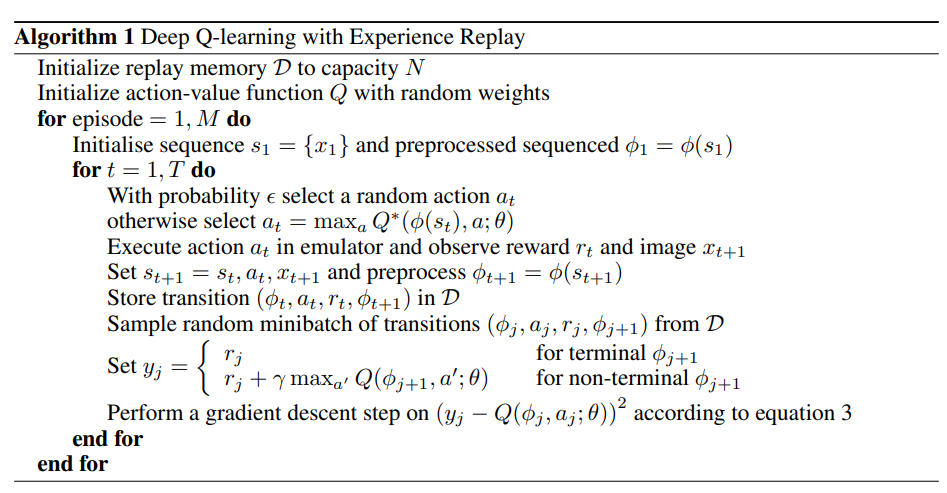

In [ ]:
%pip install gymnasium

In [ ]:
import tensorflow as tf
import numpy as np
import gymnasium as gym
import random
from collections import deque

num_episodes = 100              # The total number of episodes for training
num_exploration_episodes = 90   # The number of episodes in the exploration process
max_len_episode = 200           # The maximum number of rounds for each episode
batch_size = 32                 # batch size
learning_rate = 1e-3            # learning rate
gamma = 1.                      # discount factor
initial_epsilon = 1.            # Exploration rate at the beginning of exploration
final_epsilon = 0.01            # Exploration rate at the end of exploration


class QNetwork(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(units=24, activation=tf.nn.relu)
        self.dense2 = tf.keras.layers.Dense(units=24, activation=tf.nn.relu)
        self.dense3 = tf.keras.layers.Dense(units=2)

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return x

    def predict(self, inputs):
        q_values = self(inputs)
        return tf.argmax(q_values, axis=-1)


if __name__ =='__main__':
    env = gym.make('CartPole-v0') # Instantiate a game environment, the parameter is the game name
    model = QNetwork()
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    replay_buffer = deque(maxlen=10000) # Use a deque as the experience replay pool for Q Learning
    epsilon = initial_epsilon
    for episode_id in range(num_episodes):
        state = env.reset()[0] # Initialize the environment and get the initial state
        epsilon = max( # Calculate the current exploration rate
            initial_epsilon * (num_exploration_episodes-episode_id) / num_exploration_episodes,
            final_epsilon)
        for t in range(max_len_episode):
            # env.render() # Render the current frame and draw to the screen (offline, cannot work in colab)
            if random.random() <epsilon: # epsilon-greedy Explore strategy, choose random action with epsilon probability
                action = env.action_space.sample() # Select random action (exploration)
            else:
                action = model.predict(np.expand_dims(state, axis=0)).numpy() # Select the action with the largest Q Value calculated by the model
                action = action[0]

            # Let the environment execute the action, get the next state after the action is executed, the reward of the action, whether the game is over, and additional information
            # print(env.step(action))
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            # If the game is Game Over, give a big negative reward
            reward = -10. if done else reward
            # print(len(env.step(action)))
            # Put the four-tuple of (state, action, reward, next_state) (plus the done tag to indicate whether it is over) into the experience playback pool
            replay_buffer.append((state, action, reward, next_state, 0 if done else 1))
            # Update the current state
            state = next_state

            if done: # When the game is over, exit the current loop and proceed to the next episode
                print("episode %4d, epsilon %.4f, score %4d"% (episode_id, epsilon, t))
                break

            if len(replay_buffer) >= batch_size:
                # Randomly take a batch of quadruples from the experience replay pool and convert them to NumPy arrays respectively
                batch = random.sample(replay_buffer, batch_size)
                batch_state = np.array([replay[0] for replay in batch])
                batch_action = np.array([replay[1] for replay in batch])
                batch_reward = np.array([replay[2] for replay in batch])
                batch_next_state = np.array([replay[3] for replay in batch])
                batch_done =  np.array([replay[4] for replay in batch])

                q_value = model(batch_next_state)
                ### TODO: implement the update of Q
                y = gamma * tf.reduce_max(q_value, axis=1) * batch_done + batch_reward
                ### END TODO ###
                with tf.GradientTape() as tape:
                    mse = tf.keras.losses.MeanSquaredError()
                    loss = mse( # Minimize the distance between y and Q-value
                        y_true=y,
                        y_pred=tf.reduce_sum(model(batch_state) * tf.one_hot(batch_action, depth=2), axis=1)
                    )
                grads = tape.gradient(loss, model.variables)
                optimizer.apply_gradients(grads_and_vars=zip(grads, model.variables)) # Calculate the gradient and update the parameters

/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


episode    0, epsilon 1.0000, score   40
episode    1, epsilon 0.9889, score   16
episode    2, epsilon 0.9778, score   12
episode    3, epsilon 0.9667, score   14
episode    4, epsilon 0.9556, score   24
episode    5, epsilon 0.9444, score   10
episode    6, epsilon 0.9333, score   16
episode    7, epsilon 0.9222, score   37
episode    8, epsilon 0.9111, score   27
episode    9, epsilon 0.9000, score   19
episode   10, epsilon 0.8889, score   36
episode   11, epsilon 0.8778, score   20
episode   12, epsilon 0.8667, score   14
episode   13, epsilon 0.8556, score   48
episode   14, epsilon 0.8444, score   22
episode   15, epsilon 0.8333, score   31
episode   16, epsilon 0.8222, score   47
episode   17, epsilon 0.8111, score   24
episode   18, epsilon 0.8000, score   42
episode   19, epsilon 0.7889, score   25
episode   20, epsilon 0.7778, score   45
episode   21, epsilon 0.7667, score   12
episode   22, epsilon 0.7556, score   10
episode   23, epsilon 0.7444, score   10
episode   24, ep

The following code is for the visualization of the trained model on the CartPole task.

In [ ]:
!pip install pyvirtualdisplay
!apt-get install -y xvfb python3-opengl ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-opengl is already the newest version (3.1.5+dfsg-1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.13).
0 upgraded, 0 newly installed, 0 to remove and 29 not upgraded.


In [ ]:
from gym.wrappers.record_video import RecordVideo
import glob
import io
import base64
from IPython.display import HTML
from pyvirtualdisplay import Display
from IPython import display as ipythondisplay

display = Display(visible=0, size=(1400, 900))
display.start()

"""
Utility functions to enable video recording of gym environment
and displaying it.
To enable video, just do "env = wrap_env(env)""
"""

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")


def wrap_env(env):
  env = RecordVideo(env, './video', episode_trigger = lambda episode_number: True)
  return env

In [ ]:
env = wrap_env(gym.make('CartPole-v0', render_mode="rgb_array"))
state = env.reset()[0]
i = 0
while True:
    env.render()
    action = model.predict(np.expand_dims(state, axis=0)).numpy()[0]
    state, reward, done, info = env.step(action)
    i += 1

    if done:
        print(i)
        break;

env.close()
show_video()

/usr/local/lib/python3.11/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


200


#Reference
The illustration of VI/PI refers to:
* https://www.davidsilver.uk/wp-content/uploads/2020/03/DP.pdf

The VI/PI algorithm refers to:
* http://incompleteideas.net/book/RLbook2020.pdf

Refer code to draw the grid plot in VI/PI:
* https://www.kaggle.com/nvtnganfb/gridworld

#Advanced Mode - two models
- one for Q-network to predict Q(s,a)
- one for Target Q to predict Q(s', a')

why? and how? - answered by Grok

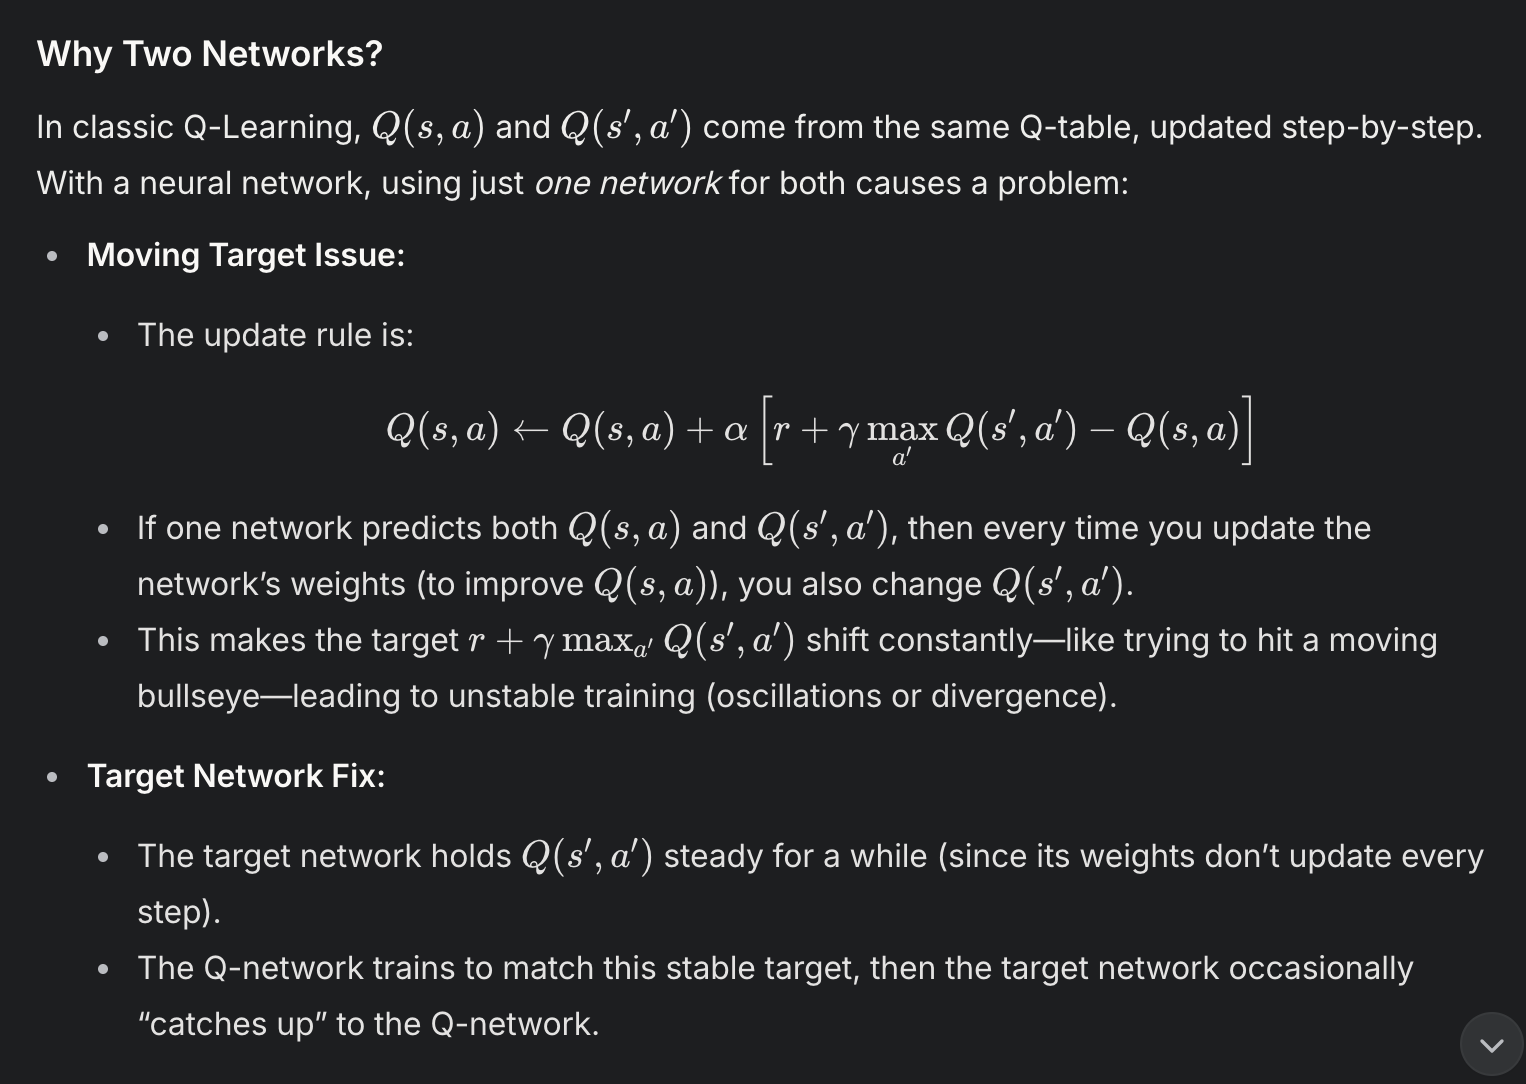

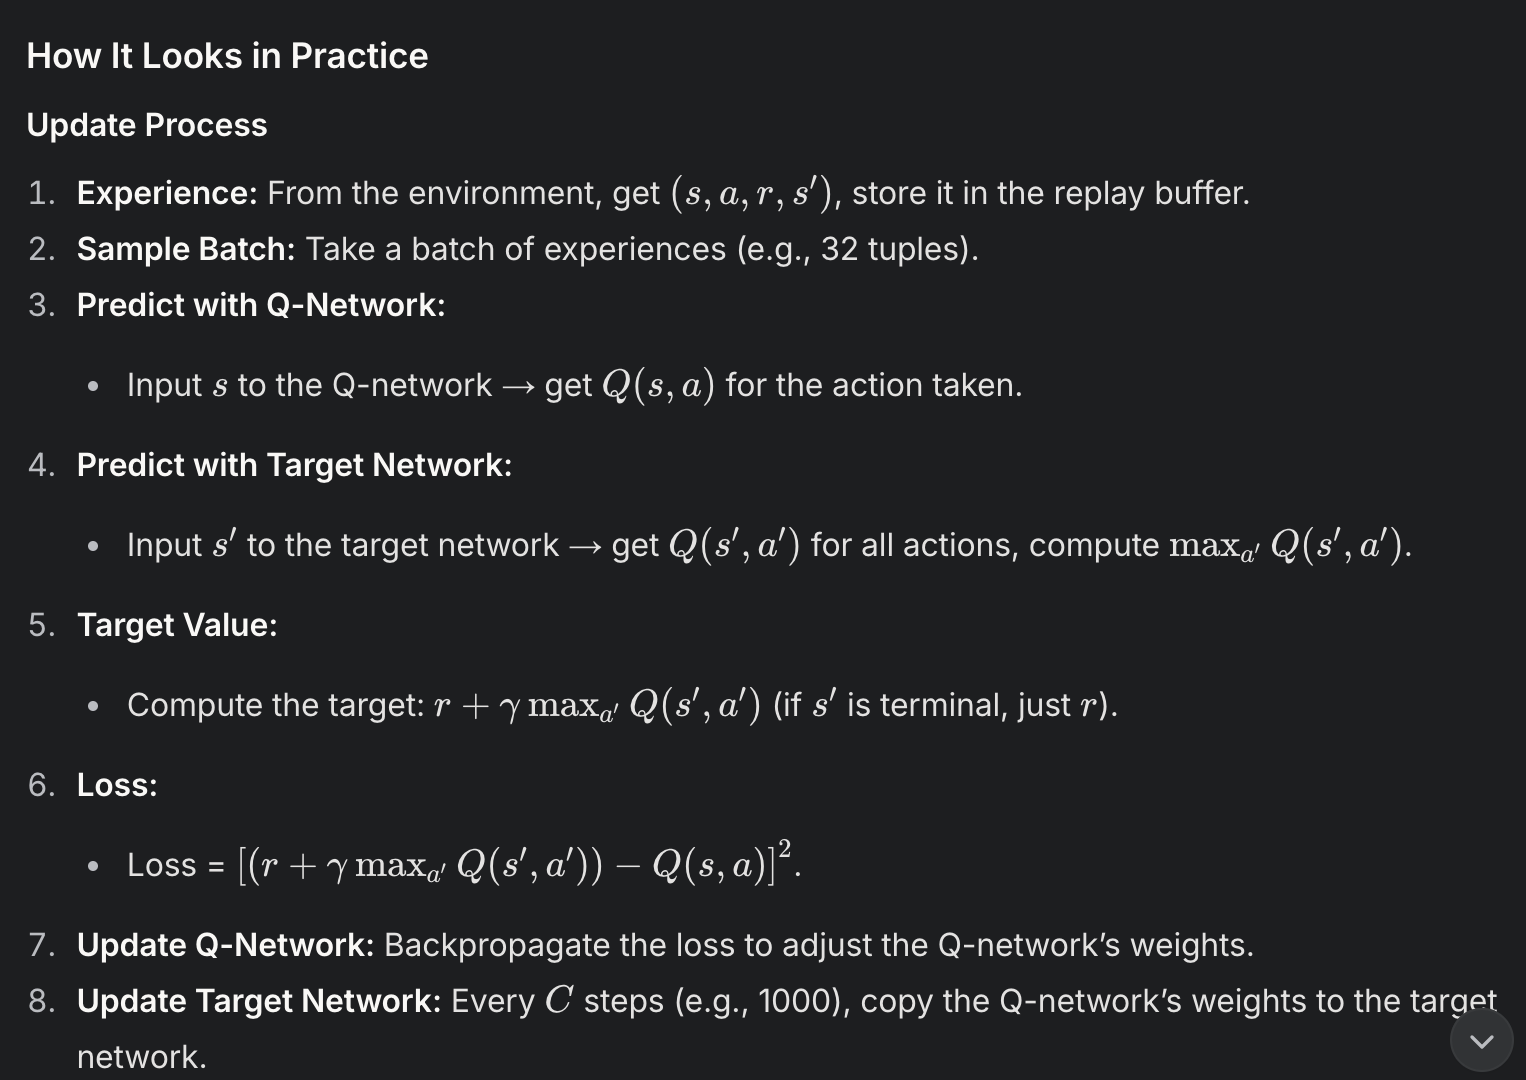

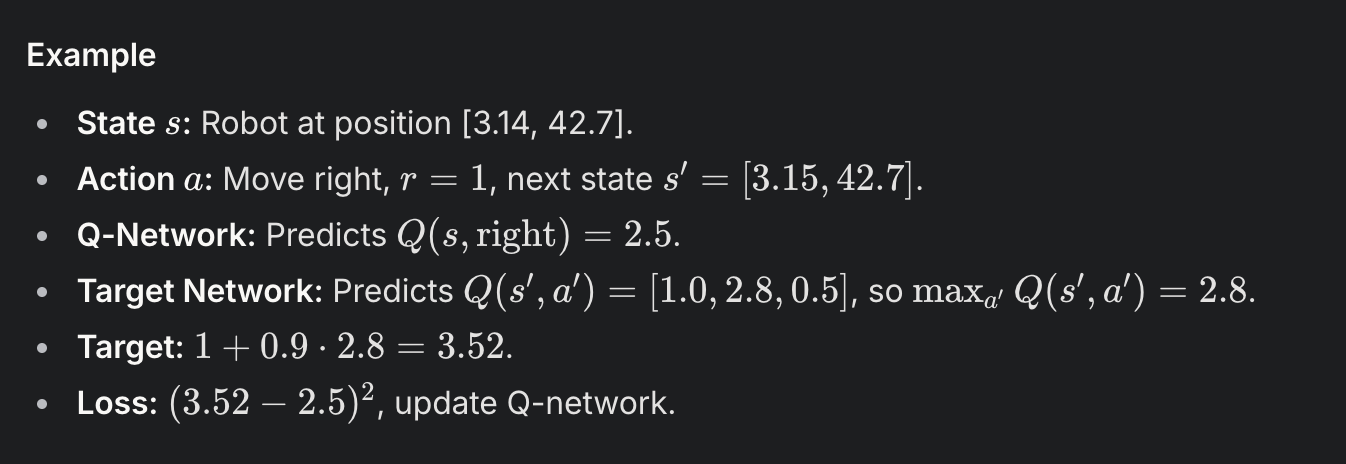